In [49]:
import os

import torch
import torch.optim as optim
from torch.nn import CrossEntropyLoss
from torch.nn import functional as F
from torch.optim import Adam, AdamW

os.environ["WANDB_API_KEY"] = "KEY"
os.environ["WANDB_MODE"] = 'offline'
from itertools import combinations

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, Dataset
import random
import csv
from torch import Tensor
import itertools
import math
import re
import numpy as np
import argparse
import pickle
import seaborn as sns
import neo
from quantities import ms
from elephant.statistics import instantaneous_rate
from elephant.kernels import GaussianKernel

from PIL import Image
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from sklearn.model_selection import train_test_split
import pandas as pd
from torch.utils.data import random_split

In [2]:
spike_inf_path = "/home/ubuntu/Documents/jct/project/sorted/251205_10k/spike_inf.tsv"
neuron_inf_path = "/home/ubuntu/Documents/jct/project/sorted/251205_10k/neuron_inf.pkl"
spike_inf = None
neuron_inf = None

spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)

with open(neuron_inf_path, 'rb') as f:
    neuron_inf = pickle.load(f)

In [3]:
trigger = pd.read_csv("/media/ubuntu/sda/duan/raw_data/251205/rec_params.csv")
trigger = trigger[trigger['bhv_codes'] == 10]
trigger = trigger.reset_index()
stimuli_pattern = pd.read_csv('/media/ubuntu/sda/visual_stimuli_pattern/things/visual_stimuli_sequence.csv').iloc[:11427, :]
trigger = pd.concat((trigger, stimuli_pattern), axis = 1)
trigger = trigger[trigger['trial_error'] == 0]
trigger['rec_codes_points'] = trigger['rec_codes_points'] / 3
trigger['start_extend'] = trigger['rec_codes_points'] - 10000 * 150 / 1000
trigger['end_points'] = trigger['rec_codes_points'] + 10000 * 300 / 1000
trigger['end_extend'] = trigger['rec_codes_points'] + 10000 * 450 / 1000

image = [i.split("/")[-1].split("_")[-1].split(".")[0] for i in trigger['image_path'].values]
trigger['image_id'] = image


In [48]:
# 仅按 test 集试次绘制，并按 test 集的 image_id 顺序（如有 test_id 则按 test_id）排序
sort_key = 'test_id' if 'test_id' in trigger.columns else 'image_id'
trigger_test = trigger[trigger['test'] == 1].copy()
trigger_test = trigger_test.sort_values(by=sort_key).reset_index(drop=True)

with PdfPages("raster_overall_test_only.pdf") as pdf:
    for neuron in spike_inf['neuron'].unique():
        neuron_df = spike_inf[spike_inf['neuron'] == neuron]

        fig, ax = plt.subplots(figsize=(12, 7.5))

        for index, row in trigger_test.iterrows():
            start = row['start_extend']
            end = row['end_extend']

            filtered_spikes = neuron_df[(neuron_df['time'] >= start) & (neuron_df['time'] <= end)]

            if not filtered_spikes.empty:
                ax.plot(filtered_spikes['time'] - start, [index] * len(filtered_spikes), marker='|', mew=1, markersize=3, ls='', color='k')

        ax.set_yticks([])
        ax.set_xlabel('time (s)')
        ax.set_ylabel("")
        ax.set_title(f'Raster Plot for {neuron} (test only, order by {sort_key})')

        pdf.savefig(fig)
        plt.close()

In [4]:
# 计算每个neuron在-150ms到+150ms窗口的瞬时发放率
sample_rate = 10000  # Hz
sampling_period_ms = 10
gk = GaussianKernel(20 * ms)

neurons = neuron_inf['Neuron'].values
n_neurons = len(neurons)
n_trials = len(trigger)

spikes_by_neuron = {
    n: spike_inf.loc[spike_inf['neuron'] == n, 'time'].to_numpy(dtype=np.int64)
    for n in neurons
}

time_bins = None
firing_rate_matrix = None
time_axis_ms = None

for trial_idx, (_, trial) in enumerate(trigger.iterrows()):
    start = int(trial['rec_codes_points'])
    end = int(trial['end_points'])
    window_ms = 300

    for neuron_idx, neuron_name in enumerate(neurons):
        spikes = spikes_by_neuron[neuron_name]
        mask = (spikes >= start) & (spikes <= end)
        relative_spikes_ms = (spikes[mask] - start) / (sample_rate / 1000)

        temp_spiketrain = neo.SpikeTrain(
            relative_spikes_ms * ms, t_stop=window_ms * ms, t_start=0 * ms
        )
        rates = instantaneous_rate(
            temp_spiketrain, kernel=gk, sampling_period=sampling_period_ms * ms
        ).magnitude.flatten()

        if time_bins is None:
            time_bins = len(rates)
            firing_rate_matrix = np.zeros((n_neurons, time_bins, n_trials))
            time_axis_ms = np.arange(0, time_bins * sampling_period_ms, sampling_period_ms)
        elif len(rates) != time_bins:
            raise ValueError(
                f'发现不一致的time_bins长度: {len(rates)} (trial {trial_idx})，预期 {time_bins}'
            )

        firing_rate_matrix[neuron_idx, :, trial_idx] = rates

print('firing_rate_matrix shape:', firing_rate_matrix.shape)


firing_rate_matrix shape: (101, 30, 10341)


In [5]:
time_bins = firing_rate_matrix.shape[1]
n_trials = firing_rate_matrix.shape[2]
assert len(trigger) == n_trials, f"trigger行数({len(trigger)})需与firing_rate_matrix trial数({n_trials})一致"


# trial 位置索引（使用顺序位置，避免原始索引不连续导致越界）
trial_pos = np.arange(n_trials)
train_pos = trial_pos[trigger['test'].to_numpy() == 0]
test_pos = trial_pos[trigger['test'].to_numpy() == 1]

train_firing_rate_matrix = firing_rate_matrix[:, :, train_pos]
test_firing_rate_matrix = firing_rate_matrix[:, :, test_pos]

print('train_firing_rate_matrix:', train_firing_rate_matrix.shape)
print('test_firing_rate_matrix:', test_firing_rate_matrix.shape)

# 生成与 trial 对齐的元数据 CSV（train/test 各一份）
def build_meta(pos_array):
    df = trigger.iloc[pos_array][['image_path']].copy()
    if 'image_id' in trigger.columns:
        df['image_id'] = trigger.iloc[pos_array]['image_id'].values
    elif 'test_id' in trigger.columns:
        df['image_id'] = trigger.iloc[pos_array]['test_id'].values
    else:
        df['image_id'] = [int(p.split('/')[-1].split('_')[-1].split('.')[0]) for p in df['image_path']]
    return df

train_meta = build_meta(train_pos)
test_meta = build_meta(test_pos)

train_meta_path = '/media/ubuntu/sda/duan/result/251205/train_trials_meta.csv'
test_meta_path = '/media/ubuntu/sda/duan/result/251205/test_trials_meta.csv'
train_meta.to_csv(train_meta_path, index=False)
test_meta.to_csv(test_meta_path, index=False)
print('train meta saved:', train_meta_path, '| rows:', len(train_meta))
print('test meta saved:', test_meta_path, '| rows:', len(test_meta))

# 可选：保存矩阵
np.save('/media/ubuntu/sda/duan/result/251205/train_firing_rate_matrix.npy', train_firing_rate_matrix)
np.save('/media/ubuntu/sda/duan/result/251205/test_firing_rate_matrix.npy', test_firing_rate_matrix)
print('矩阵已保存到 result/251205 下（.npy）')



train_firing_rate_matrix: (101, 30, 7565)
test_firing_rate_matrix: (101, 30, 2776)
train meta saved: /media/ubuntu/sda/duan/result/251205/train_trials_meta.csv | rows: 7565
test meta saved: /media/ubuntu/sda/duan/result/251205/test_trials_meta.csv | rows: 2776
矩阵已保存到 result/251205 下（.npy）


In [6]:
np.save('firing_rate_matrix.npy', firing_rate_matrix)

In [9]:
# 对 train_firing_rate_matrix 进行非负张量分解（Non-negative PARAFAC）
# 使用 tensorly 库进行3维张量的PARAFAC分解
import tensorly as tl
from tensorly.decomposition import non_negative_parafac
import warnings
warnings.filterwarnings('ignore')

assert train_firing_rate_matrix is not None, "请先生成 train_firing_rate_matrix"

# train_firing_rate_matrix 形状: (n_neurons, time_bins, n_trials) = (121, 12, 7565)
n_neurons, time_bins, n_trials = train_firing_rate_matrix.shape

# 对每个 neuron 的响应进行归一化（以neuron为单位，对每个neuron的(n_trial, time_bin)矩阵归一化）
normalized_matrix = np.zeros_like(train_firing_rate_matrix)
for neuron_idx in range(n_neurons):
    neuron_data = train_firing_rate_matrix[neuron_idx, :, :]  # (time_bins, n_trials)
    neuron_flat = neuron_data.flatten()
    if neuron_flat.max() > neuron_flat.min():
        normalized_flat = (neuron_flat - neuron_flat.min()) / (neuron_flat.max() - neuron_flat.min())
    else:
        normalized_flat = neuron_flat
    normalized_matrix[neuron_idx, :, :] = normalized_flat.reshape(time_bins, n_trials)

print('归一化完成（以neuron为单位），数据范围:', normalized_matrix.min(), '到', normalized_matrix.max())

# 转换为tensorly张量
tensor = tl.tensor(normalized_matrix)
print('张量形状:', tensor.shape)

# 选择PARAFAC的rank（组件数）
rank = 60
print(f'使用 PARAFAC 分解，rank={rank}...')

# 执行非负PARAFAC分解
factors = non_negative_parafac(
    tensor,
    rank=rank,
    init='random',
    n_iter_max=500,
    tol=1e-6
)

# factors.factors[0]: (n_neurons, rank) - neuron factors
# factors.factors[1]: (time_bins, rank) - time factors
# factors.factors[2]: (n_trials, rank) - trial factors
# factors.weights: (rank,) - 每个组件的权重

neural_matrix = factors.factors[0]  # (n_neurons, rank)
time_matrix = factors.factors[1]    # (time_bins, rank)
trial_matrix = factors.factors[2]   # (n_trials, rank)

print('Neuron factors形状:', neural_matrix.shape)
print('Time factors形状:', time_matrix.shape)
print('Trial factors形状:', trial_matrix.shape)
print('Weights形状:', factors.weights.shape)

# 对neuron factor进行归一化和缩放（参考代码中的方法）
norms = [tl.norm(f, 2) for f in factors.factors]
lambda_vec = factors.weights * np.prod(norms, axis=0)
neural_scaled = neural_matrix * lambda_vec

print('Neural scaled形状:', neural_scaled.shape)

# 保存结果
np.save('/media/ubuntu/sda/duan/result/251205/parafac_neural_matrix.npy', neural_matrix)
np.save('/media/ubuntu/sda/duan/result/251205/parafac_time_matrix.npy', time_matrix)
np.save('/media/ubuntu/sda/duan/result/251205/parafac_trial_matrix.npy', trial_matrix)
np.save('/media/ubuntu/sda/duan/result/251205/parafac_weights.npy', factors.weights)
np.save('/media/ubuntu/sda/duan/result/251205/parafac_neural_scaled.npy', neural_scaled)
np.save('/media/ubuntu/sda/duan/result/251205/train_firing_rate_matrix_normalized.npy', normalized_matrix)
print('\n所有PARAFAC结果已保存到 result/251205 下')



归一化完成（以neuron为单位），数据范围: 0.0 到 1.0
张量形状: (121, 12, 7565)
使用 PARAFAC 分解，rank=60...
Neuron factors形状: (121, 60)
Time factors形状: (12, 60)
Trial factors形状: (7565, 60)
Weights形状: (60,)
Neural scaled形状: (121, 60)

所有PARAFAC结果已保存到 result/251205 下


In [10]:
# 可视化 PARAFAC 结果：time factors 的时间模式
assert 'time_matrix' in locals() or 'time_matrix' in globals(), "请先运行 PARAFAC 分解"

# 如果 time_matrix 不存在，从保存的文件加载
if 'time_matrix' not in locals() and 'time_matrix' not in globals():
    time_matrix = np.load('/media/ubuntu/sda/duan/result/251205/parafac_time_matrix.npy')
    neural_matrix = np.load('/media/ubuntu/sda/duan/result/251205/parafac_neural_matrix.npy')
    trial_matrix = np.load('/media/ubuntu/sda/duan/result/251205/parafac_trial_matrix.npy')
    neural_scaled = np.load('/media/ubuntu/sda/duan/result/251205/parafac_neural_scaled.npy')
    rank = time_matrix.shape[1]

print('Time factors形状:', time_matrix.shape)
print('Neural factors形状:', neural_matrix.shape)
print('Trial factors形状:', trial_matrix.shape)

# 绘制每个 time factor 的模式
pdf_path = '/media/ubuntu/sda/duan/result/251205/parafac_time_factors_pattern.pdf'
with PdfPages(pdf_path) as pdf:
    for comp_idx in range(min(rank, 20)):  # 显示前20个
        plt.figure(figsize=(10, 4))
        plt.plot(time_matrix[:, comp_idx], linewidth=2)
        plt.title(f'Time Factor {comp_idx + 1}/{rank}')
        plt.xlabel('Time bins')
        plt.ylabel('Factor Value')
        plt.grid(True, alpha=0.3)
        pdf.savefig()
        plt.close()

pdf_path = '/media/ubuntu/sda/duan/result/251205/parafac_time_factors_pattern_combined.pdf'
with PdfPages(pdf_path) as pdf:
    plt.figure(figsize=(10, 4))
    for comp_idx in range(min(rank, 20)):  # 显示前20个
        # 获取当前时间因子数据
        time_data = time_matrix[:, comp_idx]
        
        # 归一化到0-1范围
        min_val = time_data.min()
        max_val = time_data.max()
        normalized_data = (time_data - min_val) / (max_val - min_val) if max_val != min_val else time_data * 0
        
        plt.plot(normalized_data, linewidth=2)
    
    plt.title(f'Time Factors (Normalized to 0-1)')
    plt.xlabel('Time bins')
    plt.ylabel('Normalized Factor Value')
    plt.ylim(-0.05, 1.05)  # 稍微扩展y轴范围以便更好显示
    plt.grid(True, alpha=0)
    pdf.savefig()
    plt.close()



Time factors形状: (12, 60)
Neural factors形状: (121, 60)
Trial factors形状: (7565, 60)


In [11]:
# 对每个neuron的反应矩阵进行层次聚类并绘制热图
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist

assert 'train_firing_rate_matrix' in locals() or 'train_firing_rate_matrix' in globals(), "请先生成 train_firing_rate_matrix"

# train_firing_rate_matrix 形状: (n_neurons, time_bins, n_trials)
n_neurons, time_bins, n_trials = train_firing_rate_matrix.shape
print(f"数据形状: (n_neurons={n_neurons}, time_bins={time_bins}, n_trials={n_trials})")

# 获取neuron名称
neurons = neuron_inf['Neuron'].values if 'neuron_inf' in locals() or 'neuron_inf' in globals() else [f'Neuron_{i}' for i in range(n_neurons)]

pdf_path = '/media/ubuntu/sda/duan/result/251205/neuron_hierarchical_clustering_heatmaps.pdf'

print("\n开始对每个neuron进行层次聚类...")

with PdfPages(pdf_path) as pdf:
    for neuron_idx in range(n_neurons):
        # 提取该neuron的数据: (time_bins, n_trials) -> 转置为 (n_trials, time_bins)
        neuron_data = train_firing_rate_matrix[neuron_idx, :, :].T  # (n_trials, time_bins)
        
        # 对每个trial进行归一化（z-score标准化）
        # 对每一行（每个trial）计算均值和标准差，然后标准化
        means = neuron_data.mean(axis=1, keepdims=True)
        stds = neuron_data.std(axis=1, keepdims=True)
        stds_safe = np.where(stds == 0, 1, stds)  # 避免除零
        neuron_data_normalized = (neuron_data - means) / stds_safe
        
        # 计算trial之间的距离矩阵（使用欧氏距离）
        # 对每个trial的time_bins向量计算距离
        distances = pdist(neuron_data_normalized, metric='euclidean')
        
        # 进行层次聚类（使用ward连接方法，也可以尝试'complete', 'average'等）
        linkage_matrix = linkage(distances, method='ward')
        
        # 获取聚类后的trial顺序
        trial_order = leaves_list(linkage_matrix)
        
        # 根据聚类结果重新排序数据（使用归一化后的数据）
        neuron_data_clustered = neuron_data_normalized[trial_order, :]
        
        # 绘制热图
        fig, ax = plt.subplots(figsize=(10, 12))
        
        # 使用seaborn绘制热图
        sns.heatmap(
            neuron_data_clustered,
            cmap='viridis',
            cbar=True,
            ax=ax,
            xticklabels=False,  # 不显示x轴刻度标签（时间bins太多）
            yticklabels=False,  # 不显示y轴刻度标签（trial太多）
            cbar_kws={'label': 'Normalized Firing Rate (Z-score)'}
        )
        
        # 设置标题
        neuron_name = neurons[neuron_idx] if isinstance(neurons[neuron_idx], str) else f'Neuron_{neuron_idx}'
        ax.set_title(f'{neuron_name} - Hierarchical Clustering Heatmap\n(n_trials={n_trials}, time_bins={time_bins})', 
                     fontsize=12, pad=10)
        ax.set_xlabel('Time Bins', fontsize=10)
        ax.set_ylabel('Trials (clustered)', fontsize=10)
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        
        if (neuron_idx + 1) % 10 == 0 or neuron_idx == n_neurons - 1:
            print(f"  已处理 {neuron_idx + 1}/{n_neurons} neurons")

print(f"\n✓ 层次聚类热图已保存到: {pdf_path}")
print(f"每个neuron一页，共 {n_neurons} 页")



数据形状: (n_neurons=121, time_bins=12, n_trials=7565)

开始对每个neuron进行层次聚类...
  已处理 10/121 neurons
  已处理 20/121 neurons
  已处理 30/121 neurons
  已处理 40/121 neurons
  已处理 50/121 neurons
  已处理 60/121 neurons
  已处理 70/121 neurons
  已处理 80/121 neurons
  已处理 90/121 neurons
  已处理 100/121 neurons
  已处理 110/121 neurons
  已处理 120/121 neurons
  已处理 121/121 neurons

✓ 层次聚类热图已保存到: /media/ubuntu/sda/duan/result/251205/neuron_hierarchical_clustering_heatmaps.pdf
每个neuron一页，共 121 页


Test meta shape: (2776, 2)
Test meta columns: ['image_path', 'image_id']

Test firing rate matrix shape: (n_neurons=121, time_bins=12, n_trials=2776)
Test firing rate matrix actual shape: (121, 12, 2776)

唯一image数量: 100

开始计算同一image不同trial之间的相关性...
  已处理 10/100 images
  已处理 20/100 images
  已处理 30/100 images
  已处理 40/100 images
  已处理 50/100 images
  已处理 60/100 images
  已处理 70/100 images
  已处理 80/100 images
  已处理 90/100 images
  已处理 100/100 images

✓ 计算完成！共处理 100 个images（至少有2个trial）

总体统计:
  所有image的平均correlation: 0.0063 ± 0.0111
  最小值: -0.0154
  最大值: 0.0370
  有效值数量: 100/100

结果已保存到: /media/ubuntu/sda/duan/result/251205/test_trial_repeatability.json
直方图已保存到: /media/ubuntu/sda/duan/result/251205/test_trial_repeatability_histogram.pdf


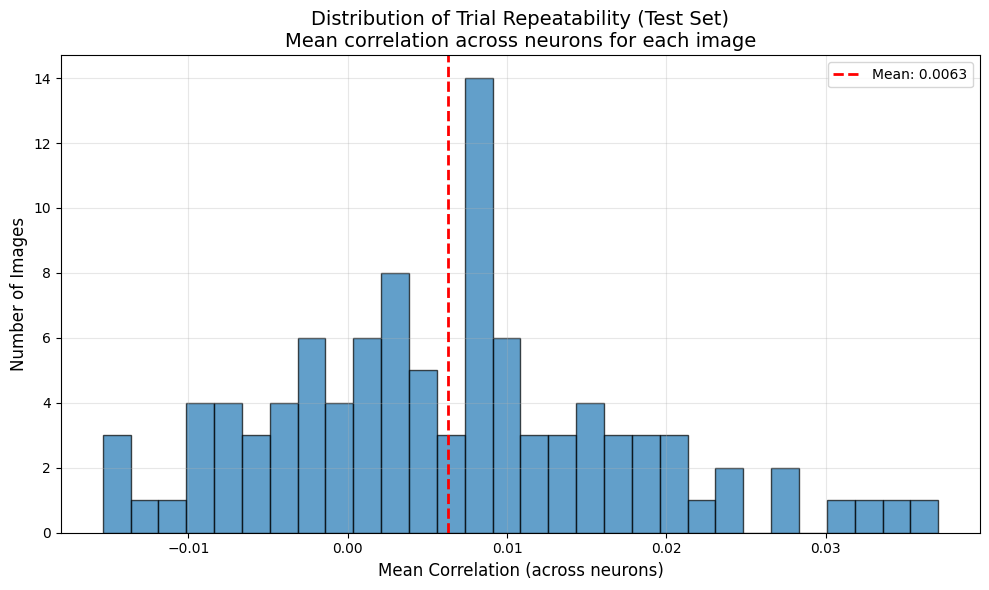

In [15]:
# 评估test_firing_rate_matrix中同一image不同trial之间的重复性
# 对于同一个image的不同trial，计算每个neuron的反应的correlation，然后求所有neuron的平均

assert 'test_firing_rate_matrix' in locals() or 'test_firing_rate_matrix' in globals(), "请先生成 test_firing_rate_matrix"

# 加载test_meta获取image_id信息
test_meta_path = '/media/ubuntu/sda/duan/result/251205/test_trials_meta.csv'
test_meta = pd.read_csv(test_meta_path)
print(f"Test meta shape: {test_meta.shape}")
print(f"Test meta columns: {test_meta.columns.tolist()}")

# test_firing_rate_matrix 形状: (n_neurons, time_bins, n_trials)
n_neurons, time_bins, n_trials = test_firing_rate_matrix.shape
print(f"\nTest firing rate matrix shape: (n_neurons={n_neurons}, time_bins={time_bins}, n_trials={n_trials})")
print(f"Test firing rate matrix actual shape: {test_firing_rate_matrix.shape}")
assert len(test_meta) == n_trials, f"Test meta length ({len(test_meta)}) 与 n_trials ({n_trials}) 不匹配"

# 获取所有唯一的image_id
image_ids = test_meta['image_id'].unique()
print(f"\n唯一image数量: {len(image_ids)}")

# 存储每个image的平均correlation（所有neuron的平均）
image_correlations = {}

print("\n开始计算同一image不同trial之间的相关性...")

for img_id in image_ids:
    # 找到该image对应的所有trial索引
    trial_mask = test_meta['image_id'] == img_id
    trial_indices = np.where(trial_mask)[0]
    n_trials_for_image = len(trial_indices)
    
    if n_trials_for_image < 2:
        # 如果该image只有一个trial，无法计算correlation，跳过
        continue
    
    # 确保trial_indices在有效范围内
    trial_indices = trial_indices[trial_indices < n_trials]
    # 重新计算n_trials_for_image，因为可能被过滤了
    n_trials_for_image = len(trial_indices)
    if n_trials_for_image < 2:
        continue
    
    # 存储每个neuron的correlation值
    neuron_correlations = []
    
    for neuron_idx in range(n_neurons):
        try:
            # 提取该neuron在该image的所有trial的反应: (n_trials_for_image, time_bins)
            # 注意：test_firing_rate_matrix 形状是 (n_neurons, time_bins, n_trials)
            # 所以访问时应该是 [neuron_idx, :, trial_indices]，然后转置
            # 确保trial_indices是numpy数组且为整数类型
            trial_indices_int = trial_indices.astype(int)
            neuron_responses = test_firing_rate_matrix[neuron_idx, :, trial_indices_int].T  # (n_trials_for_image, time_bins)
            
            # 确保neuron_responses的形状正确
            if neuron_responses.shape[0] != n_trials_for_image:
                # 如果形状不对，重新调整
                neuron_responses = neuron_responses.T if neuron_responses.shape[1] == n_trials_for_image else neuron_responses
            
            # 检查数据是否有变化（如果所有trial的反应完全相同，correlation会是NaN）
            # 检查每个trial的time_bins向量是否有变化
            row_stds = neuron_responses.std(axis=1)
            if np.all(row_stds == 0) or neuron_responses.std() == 0:
                # 如果所有trial的反应完全相同，correlation应该是1（完全相关）
                # 但为了避免NaN，我们设置为1
                mean_corr = 1.0 if n_trials_for_image > 1 else np.nan
            else:
                # 计算trial之间的correlation矩阵
                # 使用Pearson correlation，对每个trial的time_bins向量计算相关性
                # np.corrcoef 按行计算相关性，所以输入应该是 (n_trials, time_bins)
                corr_matrix = np.corrcoef(neuron_responses)  # (n_trials_for_image, n_trials_for_image)
                
                # 验证corr_matrix的形状
                actual_n_trials = corr_matrix.shape[0]
                if actual_n_trials != n_trials_for_image:
                    print(f"警告: image_id={img_id}, neuron_idx={neuron_idx}")
                    print(f"  n_trials_for_image={n_trials_for_image}, corr_matrix.shape={corr_matrix.shape}")
                    print(f"  neuron_responses.shape={neuron_responses.shape}")
                
                # 取上三角矩阵（不包括对角线，因为对角线都是1）
                # 使用np.triu_indices获取上三角索引
                # 确保使用实际的corr_matrix大小
                actual_n = corr_matrix.shape[0]
                upper_tri_indices = np.triu_indices(actual_n, k=1)
                corr_values = corr_matrix[upper_tri_indices]
                
                # 过滤掉NaN值（可能由于某些trial完全相同导致）
                corr_values_clean = corr_values[~np.isnan(corr_values)]
                
                if len(corr_values_clean) > 0:
                    # 计算该neuron的平均correlation（只使用有效值）
                    mean_corr = np.mean(corr_values_clean)
                else:
                    # 如果所有correlation都是NaN，设置为NaN
                    mean_corr = np.nan
                    
        except IndexError as e:
            print(f"错误: image_id={img_id}, neuron_idx={neuron_idx}, trial_indices={trial_indices_int}")
            print(f"trial_indices范围: [{trial_indices_int.min()}, {trial_indices_int.max()}], n_trials={n_trials}")
            print(f"test_firing_rate_matrix shape: {test_firing_rate_matrix.shape}")
            raise e
        except Exception as e:
            print(f"计算correlation时出错: image_id={img_id}, neuron_idx={neuron_idx}")
            print(f"  neuron_responses.shape={neuron_responses.shape if 'neuron_responses' in locals() else 'N/A'}")
            mean_corr = np.nan
        
        neuron_correlations.append(mean_corr)
    
    # 计算所有neuron的平均correlation（过滤掉NaN值）
    neuron_correlations_array = np.array(neuron_correlations)
    valid_neuron_corrs = neuron_correlations_array[~np.isnan(neuron_correlations_array)]
    
    if len(valid_neuron_corrs) > 0:
        image_mean_corr = np.mean(valid_neuron_corrs)
    else:
        image_mean_corr = np.nan
    
    image_correlations[img_id] = {
        'mean_correlation': image_mean_corr,
        'n_trials': n_trials_for_image,
        'n_valid_neurons': len(valid_neuron_corrs),
        'n_total_neurons': len(neuron_correlations),
        'neuron_correlations': neuron_correlations
    }
    
    if len(image_correlations) % 10 == 0:
        print(f"  已处理 {len(image_correlations)}/{len(image_ids)} images")

print(f"\n✓ 计算完成！共处理 {len(image_correlations)} 个images（至少有2个trial）")

# 计算所有image的平均correlation（过滤掉NaN值）
all_image_mean_corrs = np.array([v['mean_correlation'] for v in image_correlations.values()])
valid_corrs = all_image_mean_corrs[~np.isnan(all_image_mean_corrs)]

if len(valid_corrs) > 0:
    overall_mean_corr = np.mean(valid_corrs)
    overall_std_corr = np.std(valid_corrs)
    min_corr = np.min(valid_corrs)
    max_corr = np.max(valid_corrs)
    n_valid = len(valid_corrs)
    n_nan = len(all_image_mean_corrs) - n_valid
else:
    overall_mean_corr = np.nan
    overall_std_corr = np.nan
    min_corr = np.nan
    max_corr = np.nan
    n_valid = 0
    n_nan = len(all_image_mean_corrs)

print(f"\n总体统计:")
if n_valid > 0:
    print(f"  所有image的平均correlation: {overall_mean_corr:.4f} ± {overall_std_corr:.4f}")
    print(f"  最小值: {min_corr:.4f}")
    print(f"  最大值: {max_corr:.4f}")
    print(f"  有效值数量: {n_valid}/{len(all_image_mean_corrs)}")
    if n_nan > 0:
        print(f"  警告: {n_nan} 个image的correlation为NaN（已排除）")
else:
    print(f"  警告: 所有correlation值都是NaN！")

# 保存结果
results = {
    'overall_mean_correlation': float(overall_mean_corr) if not np.isnan(overall_mean_corr) else None,
    'overall_std_correlation': float(overall_std_corr) if not np.isnan(overall_std_corr) else None,
    'min_correlation': float(min_corr) if not np.isnan(min_corr) else None,
    'max_correlation': float(max_corr) if not np.isnan(max_corr) else None,
    'n_images': len(image_correlations),
    'n_valid_images': n_valid,
    'n_nan_images': n_nan,
    'image_correlations': {str(k): {'mean_correlation': float(v['mean_correlation']) if not np.isnan(v['mean_correlation']) else None, 
                                     'n_trials': int(v['n_trials'])} 
                           for k, v in image_correlations.items()}
}

import json
results_path = '/media/ubuntu/sda/duan/result/251205/test_trial_repeatability.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"\n结果已保存到: {results_path}")

# 可视化：绘制correlation分布直方图（只使用有效值）
if len(valid_corrs) > 0:
    plt.figure(figsize=(10, 6))
    plt.hist(valid_corrs, bins=30, edgecolor='black', alpha=0.7)
    if not np.isnan(overall_mean_corr):
        plt.axvline(overall_mean_corr, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean_corr:.4f}')
    plt.xlabel('Mean Correlation (across neurons)', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    title = 'Distribution of Trial Repeatability (Test Set)\nMean correlation across neurons for each image'
    if n_nan > 0:
        title += f'\n({n_nan} images with NaN excluded)'
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    hist_path = '/media/ubuntu/sda/duan/result/251205/test_trial_repeatability_histogram.pdf'
    plt.savefig(hist_path, dpi=300, bbox_inches='tight')
    print(f"直方图已保存到: {hist_path}")
    plt.show()
else:
    print("警告: 没有有效的correlation值可以绘制直方图")



In [18]:
np.where(test_meta['image_id'] == 61)

(array([   0,   95,   98,  239,  363,  572,  621,  638,  662,  724,  832,
         939, 1015, 1360, 1427, 1716, 1951, 2050, 2144, 2219, 2248, 2379,
        2423, 2461, 2579, 2631, 2725, 2734, 2740, 2758]),)

In [21]:
a.shape

(121, 12, 30)

In [20]:
a = test_firing_rate_matrix[:, :, np.where(test_meta['image_id'] == 61)[0]]

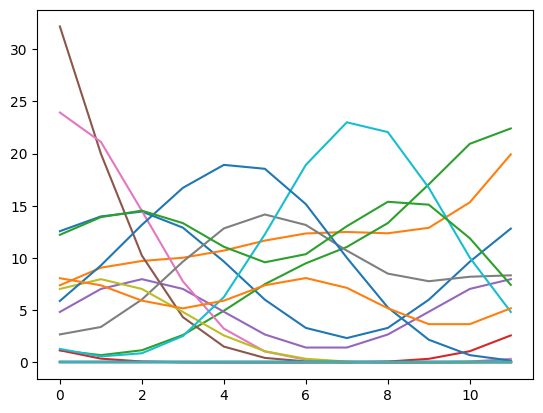

In [38]:
for i in range(30):
    sns.lineplot(a[16, :, i])

In [ ]:
a = pd.rea